# APN Dataset EDA Report: P12

本报告用于深入理解该数据集在 APN 项目中的形态、含义与时序特性。

- 覆盖内容：数据来源、样本规模、不规则采样特性、缺失模式、变量相关性、典型时序轨迹
- 注意：首次运行可能触发自动下载或预处理（取决于数据集）


## 数据集背景

P12 (PhysioNet Challenge 2012) 是 ICU 48 小时多变量监测数据。
APN 使用 36 个时序变量（不含部分静态描述符），并进行不规则建模。
其典型应用是短期临床状态预测与重建。


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if (PROJECT_ROOT / 'reports').exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from reports.irregular_eda_utils import (
    compute_dataset_summary,
    get_sample_lengths,
    plot_channel_correlation,
    plot_channel_missingness,
    plot_interarrival_distribution,
    plot_multichannel_trajectories,
    plot_sample_length_distributions,
    to_long_frame,
)

sns.set_theme(style='whitegrid', context='talk')
np.random.seed(0)


## 1) 加载数据并统一结构

将不同数据集统一为 records = [{t, x}] 形式：
- t: 一维时间戳数组
- x: 二维观测矩阵 [time, channel]


In [2]:
from data.dependencies.tsdm.tasks.P12 import Physionet2012
from reports.irregular_eda_utils import records_from_task_dataset

dataset_name = 'P12'
time_unit = 'normalized time (0-1)'

task = Physionet2012(seq_len=36 - 0.5, pred_len=3, value_norm='none')
all_ds = task.get_dataset((0, 'train'))
records = records_from_task_dataset(all_ds)
channel_names = [str(c) for c in task.dataset.columns.tolist()]
print(f'Loaded {len(records)} samples from fold-0 train split.')


/home/yixin/study/imts/APN/data/dependencies/tsdm/utils/remote.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:278: UserWarning: File 'Physionet2012-set-A-sparse.tar' cannot be validated as no hash is stored in <class 'data.dependencies.tsdm.datasets.physionet2012.Physionet2012'>.The filehash is 'd3d727077fce1e546f9cba40f87109bbce04779803ed88fb1a7ac4d644bce1ea'.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:278: UserWarning: File 'Physionet2012-set-B-sparse.tar' cannot be validated as no hash is stored in <class 'data.dependencies.tsdm.datasets.physionet2012.Physionet2012'>.The filehash is '7d8e8b78b18469884d81562d424c84e51e5405f0ae50797be7048a70202ffb3b'.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:278:

Loaded 9703 samples from fold-0 train split.


In [3]:
summary = compute_dataset_summary(records, channel_names)
lens = get_sample_lengths(records)
summary


n_samples              9703.000000
n_channels               36.000000
mean_timestamps          36.754097
median_timestamps        38.000000
mean_observations       262.032361
median_observations     263.000000
mean_duration             0.781981
dtype: float64

## 2) 样本级统计

观察每个样本时间点数量、总观测数量、时长分布。

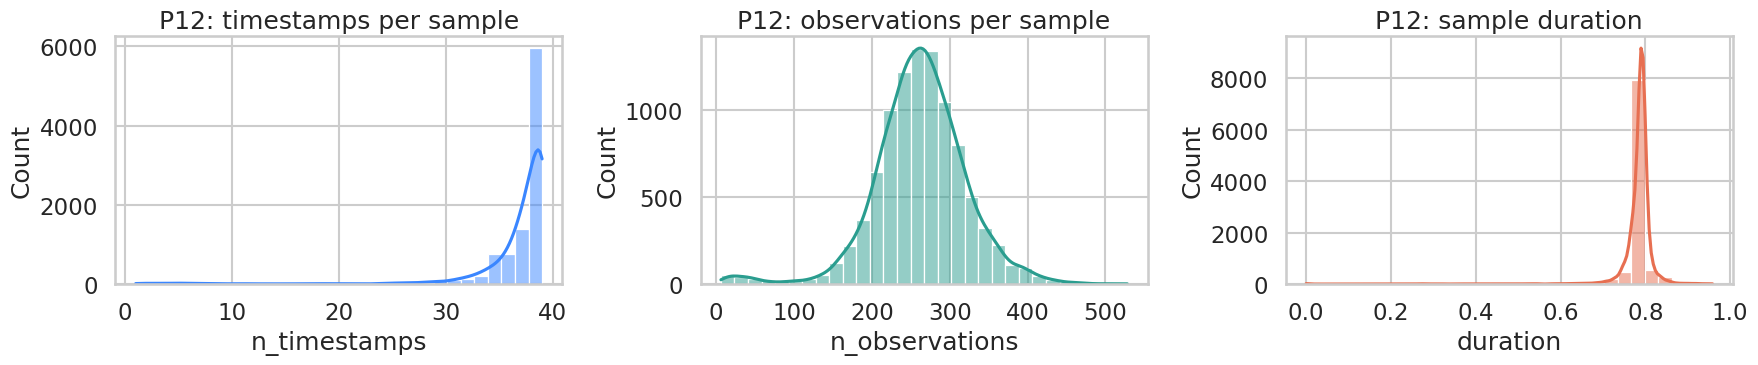

In [4]:
plot_sample_length_distributions(lens, title_prefix=f'{dataset_name}: ')

## 3) 生成长表并查看总体观测规模

In [5]:
long_df = to_long_frame(records, channel_names)
print('long_df shape:', long_df.shape)
long_df.head()


long_df shape: (2542500, 4)


,sample_id,time,channel,value
0,0,0.000000,PaCO2,39.00
1,0,0.000000,PaO2,439.00
2,0,0.000000,pH,7.34
3,0,0.020833,DiasABP,77.00
4,0,0.020833,HR,101.00


## 4) 缺失与稀疏模式（样本 x 通道）

热图显示 log(1 + 观测次数)，越亮表示该通道在该样本中记录越密集。

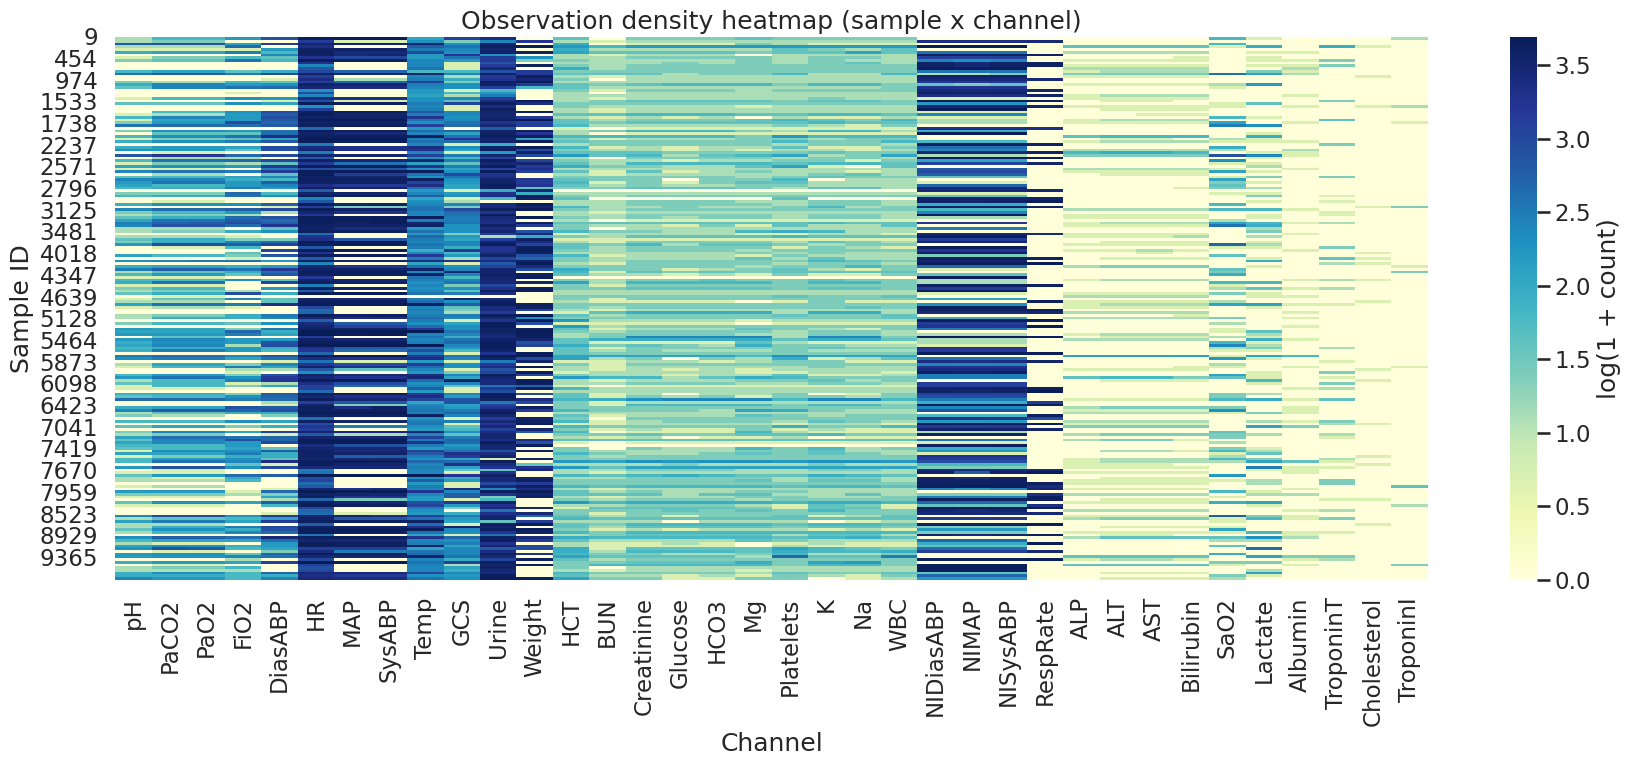

In [6]:
plot_channel_missingness(long_df, channel_names, n_samples=200)

## 5) 采样间隔分布

衡量不规则性：如果分布非常分散，说明采样时间并不均匀。

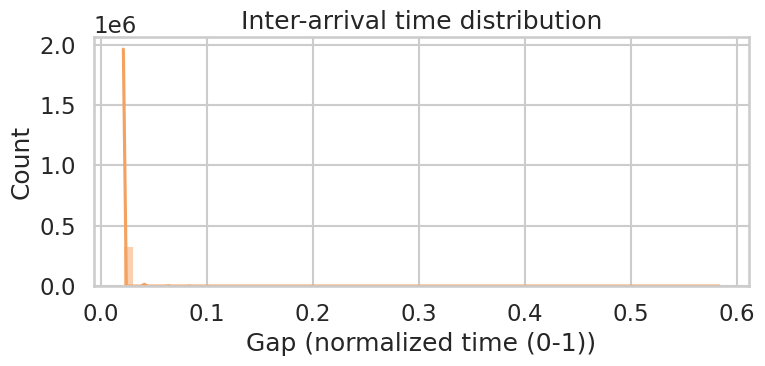

In [7]:
plot_interarrival_distribution(records, time_unit=time_unit)

## 6) 多变量时序轨迹（随机样本）

显示若干关键通道的多样本轨迹叠加。

In [8]:
preferred = ['HR', 'MAP', 'RespRate', 'Temp']
channels_to_plot = [c for c in preferred if c in channel_names]
if len(channels_to_plot) < 2:
    channels_to_plot = channel_names[:4]
channels_to_plot


['HR', 'MAP', 'RespRate', 'Temp']

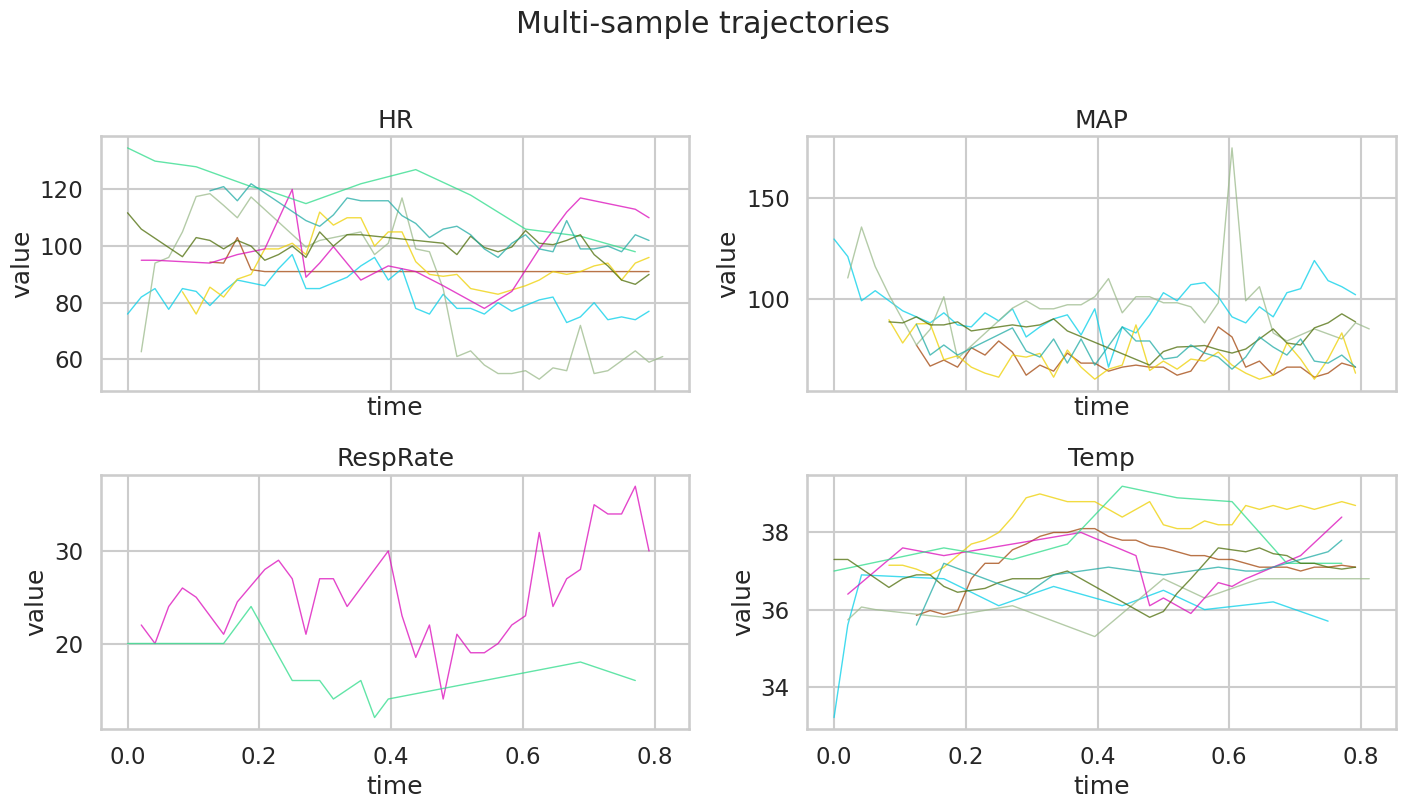

In [9]:
plot_multichannel_trajectories(long_df, channels=channels_to_plot, n_samples=8)

## 7) 通道相关性

基于“每个样本每个通道的均值”估计变量之间的相关结构。

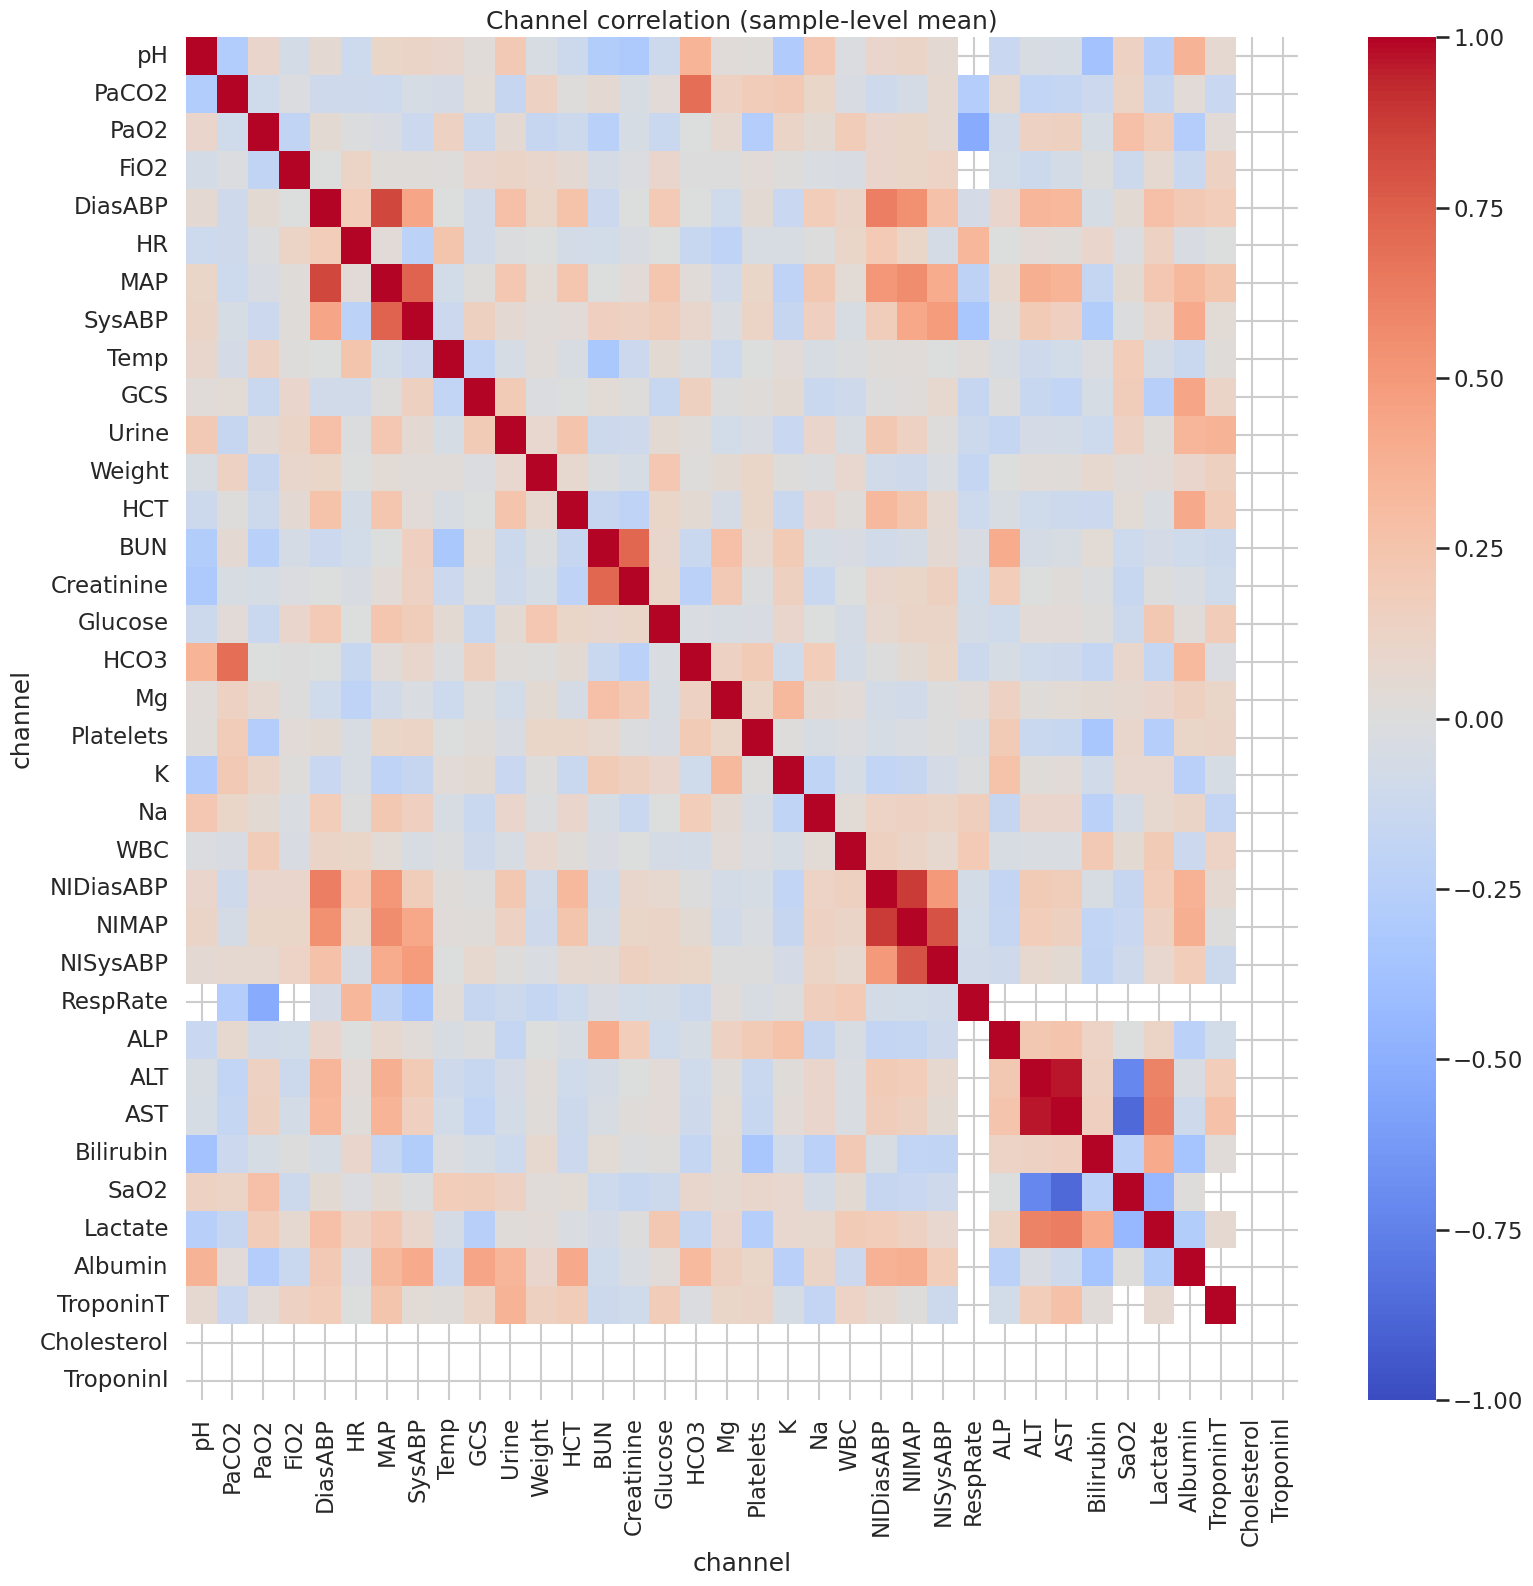

In [10]:
plot_channel_correlation(long_df, channel_names, max_samples=300)

## 8) 结论模板

你可以根据上面的图与统计，从以下角度总结：
1. 数据规模与稀疏程度：样本数、每样本观测数、时长分布
2. 不规则时间特征：时间间隔是否长尾、是否存在明显采样节律
3. 变量信息密度：哪些通道最稀疏、哪些最稳定
4. 变量联动关系：相关热图是否出现明显块状结构
5. 建模启发：是否适合 patch、插值、显式时间编码等策略
